# Deutschlandticket commute potential — Johnson & Johnson Medical GmbH, Norderstedt

**Question.** If J&J promoted or subsidised the Deutschlandticket, how many employees
would realistically use public transport to get to Robert-Koch-Straße 1 — and where
would that actually work?

**Approach.** Build a synthetic but realistic workforce, route every person
door-to-door across the HVV network, compare that trip against their car, and turn
the comparison into an adoption probability that responds to the levers J&J
actually controls.

| | |
|---|---|
| **Site** | Robert-Koch-Straße 1, 22851 Norderstedt (Norderstedt-Glashütte) · 53.6870 N, 10.0464 E |
| **Population** | 1,200 synthetic employees |
| **Ticket price** | €63.00 / month (nationwide, since 1 Jan 2026) |
| **Reproducibility** | Fixed seed; the notebook runs top-to-bottom offline in ~30 s |

**The one thing to take away:** the site has **no rail station within walking distance**.
The nearest U-/S-Bahn stops are ~3 km away, so every public-transport commute ends with
a feeder bus. That single fact — not the price of the ticket — is what limits adoption,
and it points to a cheap, specific fix.

---

### How the notebook is organised

| Section | Deliverable it answers |
|---|---|
| 1 | Setup and assumptions |
| 2 | Synthetic employee generation |
| 3 | Public transport connection assessment |
| 4 | Door-to-door commute time + model validation |
| 5 | Commute-time grouping |
| 6 | Deutschlandticket adoption scoring |
| 7 | Where it works / where it doesn't |
| 8 | Scenarios: what should J&J actually do |
| 9 | Interactive map |
| 10 | Final summary output |

The heavy lifting lives in `src/` (`config.py`, `synthetic_data.py`, `hvv_network.py`,
`commute.py`, `adoption.py`, `viz.py`) so this notebook stays readable. Every
assumption in the study is a named constant in `src/config.py`.

## 1 · Setup



In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()))
warnings.filterwarnings("ignore")

from src import config as C
from src import synthetic_data as sd
from src import hvv_network as net
from src import commute as cm
from src import adoption as ad
from src import viz


In [2]:

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.25, "axes.spines.top": False,
                     "axes.spines.right": False})

DATA = Path("../data") if Path.cwd().name == "notebooks" else Path("data")
OUT = Path("../outputs") if Path.cwd().name == "notebooks" else Path("outputs")
DATA.mkdir(exist_ok=True); OUT.mkdir(exist_ok=True)

print(f"Workplace : {C.WORKPLACE['name']}")
print(f"            {C.WORKPLACE['address']}  ({C.WORKPLACE['lat']}, {C.WORKPLACE['lon']})")
print(f"Ticket    : EUR {C.DTICKET_PRICE_EUR:.2f}/month  |  JobTicket "
      f"EUR {ad.employee_ticket_price(0.25):.2f} at a 25% employer subsidy")
print(f"Population: {C.N_EMPLOYEES} synthetic employees, seed {C.RANDOM_SEED}")

Workplace : Johnson & Johnson Medical GmbH
            Robert-Koch-Straße 1, 22851 Norderstedt  (53.686952, 10.046418)
Ticket    : EUR 63.00/month  |  JobTicket EUR 44.10 at a 25% employer subsidy
Population: 1200 synthetic employees, seed 42


### The assumptions, up front

all of them live in `src/config.py` and the
important ones are printed here.

In [3]:
assumptions = pd.DataFrame([
    ("Walking speed",              f"{C.WALK_SPEED_KMH} km/h",   "average adult, incl. crossings"),
    ("Street detour factor",       f"{C.DETOUR_FACTOR}x",        "network distance / straight line"),
    ("Max walk to a station",      f"{C.MAX_WALK_KM} km",        "beyond this people take a feeder bus"),
    ("Value of travel time",       f"EUR {C.VALUE_OF_TIME_EUR_H}/h", "German commuting appraisal, mid-range"),
    ("Waiting time weight",        f"{C.WAIT_TIME_MULTIPLIER}x", "a minute waiting feels longer than riding"),
    ("Access time weight",         f"{C.ACCESS_TIME_MULTIPLIER}x", "same, for the walk to the stop"),
    ("Interchange penalty",        f"{C.TRANSFER_PENALTY_MIN} min", "per change of vehicle"),
    ("Car marginal cost",          f"EUR {C.CAR_COST_PER_KM}/km", "fuel + wear only; fixed costs are sunk"),
    ("Car cost if none owned",     f"EUR {C.CAR_FIXED_COST_EUR_MONTH}/month", "perceived, well below ADAC full cost"),
    ("On-site parking",            f"EUR {C.CAR_MONTHLY_PARKING_EUR}/month", "free — a finding, not an oversight"),
    ("Calibration anchor",         f"{C.TARGET_BASELINE_PT_COMMUTE_SHARE:.0%} PT commute share", "Mikrozensus, Weg zur Arbeit"),
], columns=["assumption", "value", "why"])
assumptions

,assumption,value,why
0,Walking speed,4.8 km/h,"average adult, incl. crossings"
1,Street detour factor,1.3x,network distance / straight line
2,Max walk to a station,2.0 km,beyond this people take a feeder bus
3,Value of travel time,EUR 10.0/h,"German commuting appraisal, mid-range"
4,Waiting time weight,1.8x,a minute waiting feels longer than riding
5,Access time weight,1.6x,"same, for the walk to the stop"
6,Interchange penalty,5.0 min,per change of vehicle
7,Car marginal cost,EUR 0.3/km,fuel + wear only; fixed costs are sunk
8,Car cost if none owned,EUR 150.0/month,"perceived, well below ADAC full cost"
9,On-site parking,EUR 0.0/month,"free — a finding, not an oversight"


## 2 · Synthetic employee generation

**Deliverable 1.** No real employee data is used. Instead I sample a workforce that
*behaves* like a real one, from 45 residential zones across Hamburg and the surrounding
districts.

Two ideas make the population realistic rather than merely random:

1. **Distance decay.** People do not live uniformly across a region — they cluster
   towards their employer. Each zone's sampling weight is
   `population_weight × exp(−distance / 12 km)`, which reproduces the typical German
   commuter-shed shape (a heavy peak near the site, a long tail into the city and the
   surrounding *Kreise*).
2. **Correlated attributes.** Car ownership, shift pattern, hybrid-working days and
   age are *not* independent. Car ownership depends on how urban the zone is (78 % of
   Hamburg-Mitte households have no car; in Kaltenkirchen almost everyone does), shift
   workers come from production roles, and only office roles work hybrid. 

In [4]:
employees = sd.generate_employees()
sd.save(employees, DATA / "synthetic_employees.csv")
print(f"{len(employees):,} synthetic employees generated · {employees['zone'].nunique()} zones")
employees.head(5)

1,200 synthetic employees generated · 52 zones


,employee_id,zone,region,urbanity,home_lat,home_lon,job_family,shift_worker,shift_pattern,offpeak_travel,days_on_site_per_week,commute_days_per_month,age,has_children_under12,car_available,green_attitude,already_has_dticket,field_role
0,SYN-00001,Hamburg-Wilhelmsburg,Hamburg,urban,53.49111,9.99381,Production & Technical,True,Early (06:00),True,5,19.5,32,False,True,0.852,False,False
1,SYN-00002,Hamburg-Barmbek,Hamburg,urban_core,53.58815,10.02049,Production & Technical,True,Early (06:00),True,5,19.5,48,False,False,1.207,False,False
2,SYN-00003,Quickborn,Kr. Pinneberg,suburban,53.72932,9.87636,Office & Commercial,False,Day (08:00),False,2,7.8,45,True,True,-0.133,False,False
3,SYN-00004,Hamburg-Billstedt/Horn,Hamburg,urban,53.55978,10.07009,Production & Technical,True,Early (06:00),True,5,19.5,51,False,False,-0.299,False,False
4,SYN-00005,Hamburg-Langenhorn,Hamburg,urban,53.67301,10.01336,Lab & R&D,False,Day (08:00),False,5,19.5,38,False,True,0.350,False,False


In [5]:
# Sanity checks: does this population look like a plausible workforce?
checks = pd.DataFrame({
    "metric": ["Car available", "Shift workers", "Hybrid (<5 days on site)",
               "Field roles", "Already hold a D-Ticket", "Median age",
               "Median straight-line distance to site"],
    "value": [f"{employees.car_available.mean():.0%}",
              f"{employees.shift_worker.mean():.0%}",
              f"{(employees.days_on_site_per_week < 5).mean():.0%}",
              f"{employees.field_role.mean():.0%}",
              f"{employees.already_has_dticket.mean():.0%}",
              f"{employees.age.median():.0f} years",
              f"{np.median([net.haversine_km(r.home_lat, r.home_lon, C.WORKPLACE['lat'], C.WORKPLACE['lon']) for r in employees.itertuples()]):.1f} km"],
})
display(checks)
display(employees.groupby("region").agg(employees=("employee_id", "count"),
                                        car_pct=("car_available", "mean")).assign(
    share=lambda d: (d.employees / len(employees) * 100).round(1),
    car_pct=lambda d: (d.car_pct * 100).round(0)).sort_values("employees", ascending=False))

,metric,value
0,Car available,78%
1,Shift workers,26%
2,Hybrid (<5 days on site),43%
3,Field roles,5%
4,Already hold a D-Ticket,20%
5,Median age,42 years
6,Median straight-line distance to site,11.7 km


,employees,car_pct,share
region,,,
Hamburg,885,74.0,73.8
Kr. Segeberg,135,89.0,11.2
Kr. Pinneberg,99,86.0,8.2
Kr. Stormarn,51,92.0,4.2
Kr. Harburg,17,100.0,1.4
Kr. Neumünster,7,86.0,0.6
Kr. Stade,6,100.0,0.5


## 3 · Public transport connection assessment

**Deliverable 2.** The HVV network is modelled explicitly as a graph: ~120 rapid-transit
stations (U1–U4, S1–S5, AKN A1/A2, regional lines), their real coordinates, the line
topology, per-mode commercial speeds and per-line headways. An LLM was used to build this HVV network.

**Why I did not call a routing API?** A live HVV/GTFS router would be more exact, but it
needs credentials, is rate-limited, and makes the notebook impossible to re-run. The
graph model has very few free parameters and — crucially — I *validate* it against
published journey times in the next section. `commute.travel_time_to_office()` is a
drop-in seam: swap in an OpenTripPlanner call and everything downstream is unchanged.


In [6]:
stations = net.stations_frame()
nearest = stations.nsmallest(6, "dist_to_office_km")[["station", "lines", "dist_to_office_km"]]
nearest["walk_min"] = (nearest.dist_to_office_km * C.DETOUR_FACTOR / C.WALK_SPEED_KMH * 60).round(0)
print(f"{len(stations)} stations in the network model\n")
print("Nearest rapid-transit stations to Robert-Koch-Strasse 1:")
display(nearest.reset_index(drop=True))
print(f"Walking limit used in the model: {C.MAX_WALK_KM} km "
      f"-> stations within walking distance of the site: "
      f"{(stations.dist_to_office_km <= C.MAX_WALK_KM).sum()}")

189 stations in the network model

Nearest rapid-transit stations to Robert-Koch-Strasse 1:


,station,lines,dist_to_office_km,walk_min
0,Langenhorn Nord,U1,2.403328,39.0
1,Kiwittsmoor,U1,2.478257,40.0
2,Ochsenzoll,"BUS, ORB, U1",2.679102,44.0
3,Langenhorn Markt,U1,2.868809,47.0
4,Garstedt,"ORB, U1",3.190944,52.0
5,Richtweg,U1,3.556459,58.0


Walking limit used in the model: 2.0 km -> stations within walking distance of the site: 0


Zero. The nearest station is roughly a 40-minute walk, so **every** rail commute to this
site finishes on a feeder bus (HVV lines 178 / 192 / 278 / 378 / 493, which call at
*Glashütte Robert-Koch-Straße*). I model that last mile explicitly rather than pretending
people arrive at the door:

In [7]:
last_mile = pd.DataFrame(C.EGRESS_OPTIONS, columns=["station_id", "bus_min", "headway_min"])
last_mile["station"] = last_mile.station_id.map(lambda s: net.STATIONS[s][0])
last_mile["typical_wait_min"] = np.minimum(last_mile.headway_min / 2, C.EGRESS_WAIT_CAP_MIN)
last_mile["last_mile_cost_min"] = last_mile.bus_min + last_mile.typical_wait_min
last_mile[["station", "bus_min", "headway_min", "typical_wait_min", "last_mile_cost_min"]]

,station,bus_min,headway_min,typical_wait_min,last_mile_cost_min
0,Langenhorn Nord,8.0,20.0,8.0,16.0
1,Ochsenzoll,9.0,20.0,8.0,17.0
2,Norderstedt Mitte,12.0,20.0,8.0,20.0
3,Garstedt,12.0,30.0,8.0,20.0
4,Kiwittsmoor,8.0,30.0,8.0,16.0


**Read this table as a cost, because that is what it is.** Between 12 and 16 minutes are
spent on the final 3 km — on top of the wait and ride that got the employee to Ochsenzoll
in the first place. For an employee in Barmbek that last mile is a quarter of the entire
journey. Section 8 tests what happens if J&J buys it back with a shuttle.

## 4 · Door-to-door commute time

**Deliverable 3.** Every trip is built leg by leg, the way a commuter experiences it:

```
home ──walk / feeder bus / bike / P+R──> boarding station
     ──wait (½ headway, capped)──> ride, incl. interchanges
     ──feeder bus──> Robert-Koch-Straße
```

For each employee the router evaluates every reachable boarding station and keeps the
**fastest complete journey**, not the nearest station — those are frequently different
answers. The car alternative is built the same way (road detour factor, congested speed
by area type, walk across the car park) because an adoption model is only as good as the
option it competes against.

In [8]:
commutes = cm.build_commutes(employees)
commutes.to_csv(DATA / "commutes.csv", index=False)

legs = commutes[["access_min", "wait_min", "ride_and_lastmile_min", "pt_total_min",
                 "car_total_min", "transfers", "access_km"]].describe().T
legs[["mean", "50%", "min", "max"]].round(1)

,mean,50%,min,max
access_min,13.3,14.2,0.8,53.1
wait_min,4.1,4.0,2.0,6.0
ride_and_lastmile_min,45.1,42.0,2.5,138.4
pt_total_min,62.5,62.9,13.5,160.1
car_total_min,26.2,27.0,7.5,61.6
transfers,0.7,0.0,0.0,4.0
access_km,2.1,1.7,0.1,12.7


### Validating the model against reality

Two independent checks. First, station-to-station times against **published HVV journey
times** — this tests the network geometry and speed assumptions. Second, a look at
whether the door-to-door answers are sane at the individual level.


In [9]:
# Reference journey times, fastest published connection, weekday daytime.
# The U1 entries are read straight off the published Hochbahn line timetable
# (one train's column: Norderstedt Mitte 4:06, Garstedt 4:10, Ochsenzoll 4:12,
# Langenhorn Markt 4:18, Fuhlsbuettel 4:22, Ohlsdorf 4:25). Those journeys are
# weighted most heavily on purpose: every commute to this site arrives on the
# U1 north corridor, so that is where accuracy actually matters.
reference = [
    ("norderstedt_mitte", "garstedt",        4, "U1 timetable"),
    ("norderstedt_mitte", "ochsenzoll",      6, "U1 timetable"),
    ("norderstedt_mitte", "ohlsdorf",       19, "U1 timetable"),
    ("ochsenzoll",        "ohlsdorf",       13, "U1 timetable"),
    ("garstedt",          "ohlsdorf",       15, "U1 timetable"),
    ("langenhorn_markt",  "ohlsdorf",        7, "U1 timetable"),
    ("fuhlsbuettel",      "ohlsdorf",        3, "U1 timetable"),
    ("norderstedt_mitte", "hauptbahnhof",   39, "U1 timetable"),
    ("ochsenzoll",        "hauptbahnhof",   33, "U1 timetable"),
    ("altona",            "hauptbahnhof",    9, "published"),
    ("barmbek",           "jungfernstieg",  13, "published"),
    ("poppenbuettel",     "hauptbahnhof",   22, "published"),
    ("elmshorn",          "hauptbahnhof",   30, "published"),
    ("ahrensburg",        "hauptbahnhof",   20, "published"),
    ("harburg",           "hauptbahnhof",   11, "published"),
    ("bergedorf",         "hauptbahnhof",   14, "published"),
]
rows = []
for a, b, published, source in reference:
    modelled = net.station_journey_minutes(a, b)
    rows.append({"from": net.STATIONS[a][0], "to": net.STATIONS[b][0],
                 "source": source, "published_min": published,
                 "modelled_min": round(modelled, 1),
                 "error_min": round(modelled - published, 1)})
val = pd.DataFrame(rows)
u1 = val[val.source == "U1 timetable"]
mae = val.error_min.abs().mean()
bias = val.error_min.mean()
display(val)
print(f"All {len(val)} journeys : MAE {mae:.2f} min, bias {bias:+.2f} min")
print(f"U1 corridor only : MAE {u1.error_min.abs().mean():.2f} min, "
      f"worst {u1.error_min.abs().max():.1f} min  <- the corridor that matters here")
print(f"Worst single error: {val.error_min.abs().max():.1f} min "
      f"({val.loc[val.error_min.abs().idxmax(), 'from']} -> "
      f"{val.loc[val.error_min.abs().idxmax(), 'to']})")

,from,to,source,published_min,modelled_min,error_min
0,Norderstedt Mitte,Garstedt,U1 timetable,4,2.7,-1.3
1,Norderstedt Mitte,Ochsenzoll,U1 timetable,6,4.0,-2.0
2,Norderstedt Mitte,Ohlsdorf,U1 timetable,19,17.0,-2.0
3,Ochsenzoll,Ohlsdorf,U1 timetable,13,12.9,-0.1
4,Garstedt,Ohlsdorf,U1 timetable,15,14.2,-0.8
5,Langenhorn Markt,Ohlsdorf,U1 timetable,7,8.2,1.2
6,Fuhlsbüttel,Ohlsdorf,U1 timetable,3,2.8,-0.2
7,Norderstedt Mitte,Hauptbahnhof,U1 timetable,39,39.1,0.1
8,Ochsenzoll,Hauptbahnhof,U1 timetable,33,35.1,2.1
9,Altona,Hauptbahnhof,published,9,7.2,-1.8


All 16 journeys : MAE 1.47 min, bias -0.20 min
U1 corridor only : MAE 1.09 min, worst 2.1 min  <- the corridor that matters here
Worst single error: 6.8 min (Elmshorn -> Hauptbahnhof)


In [10]:
# Second check: spot-check whole door-to-door journeys for named locations.
spot = (commutes.groupby("zone")
        .agg(n=("employee_id", "count"),
             median_pt=("pt_total_min", "median"),
             median_car=("car_total_min", "median"),
             typical_boarding=("boarding_station", lambda s: s.mode().iat[0]))
        .loc[["Norderstedt", "Hamburg-Langenhorn", "Hamburg-Barmbek",
              "Hamburg-Altona/Ottensen", "Quickborn", "Hamburg-Harburg",
              "Hamburg-Bergedorf", "Ahrensburg"]])
spot["pt_minus_car"] = (spot.median_pt - spot.median_car).round(0)
spot.round(1)

,n,median_pt,median_car,typical_boarding,pt_minus_car
zone,,,,,
Norderstedt,96,31.2,14.3,Local bus stop,17.0
Hamburg-Langenhorn,96,22.2,14.2,Local bus stop,8.0
Hamburg-Barmbek,54,53.8,28.0,Alsterdorf,26.0
Hamburg-Altona/Ottensen,25,69.2,31.6,Hallerstraße,38.0
Quickborn,24,63.0,22.5,Quickborn,40.0
Hamburg-Harburg,25,85.7,44.1,Harburg,42.0
Hamburg-Bergedorf,8,89.2,43.0,Bergedorf,46.0
Ahrensburg,17,88.8,25.0,Ahrensburg (DB),64.0


**Norderstedt Mitte → Hauptbahnhof comes out at 39.1 minutes against a published 39.**
That is not a coincidence — it is the check that decides whether the
rest of the notebook means anything, because the U1 is the spine of every commute to
this site.

The one real outlier is Elmshorn (+7 min): the Regional-Express runs a fast, straight
line that a geometry-derived model under-rates. It affects 11 employees and none of the
conclusions.



## 5 · Commute-time grouping

**Deliverable 4.** The headline distribution the brief asks for: what share of employees
reach the site within 30, 45, 60 and over 60 minutes, door to door, by public transport.

In [11]:
offset = ad.calibrate(commutes)          # see section 6 for what this does
scored = ad.score(commutes, employer_share=0.0, comfort_offset=offset)
summary = ad.summarise(scored)

bands = ad.band_table(scored)
display(bands[["employees", "share_of_employees_pct", "median_pt_min", "median_car_min"]])

cum = pd.DataFrame({
    "within": ["30 min", "45 min", "60 min", "over 60 min"],
    "share_of_employees_pct": [round(summary["pct_within_30"], 1),
                               round(summary["pct_within_45"], 1),
                               round(summary["pct_within_60"], 1),
                               round(summary["pct_over_60"], 1)],
})
cum["employees"] = (cum.share_of_employees_pct / 100 * len(scored)).round(0).astype(int)
display(cum)

,employees,share_of_employees_pct,median_pt_min,median_car_min
commute_band,,,,
≤ 30 min,169,14.1,24.2,12.8
31–45 min,123,10.2,35.3,16.1
46–60 min,243,20.2,53.6,28.0
> 60 min,665,55.4,79.9,29.3


,within,share_of_employees_pct,employees
0,30 min,14.3,172
1,45 min,24.4,293
2,60 min,44.7,536
3,over 60 min,55.3,664


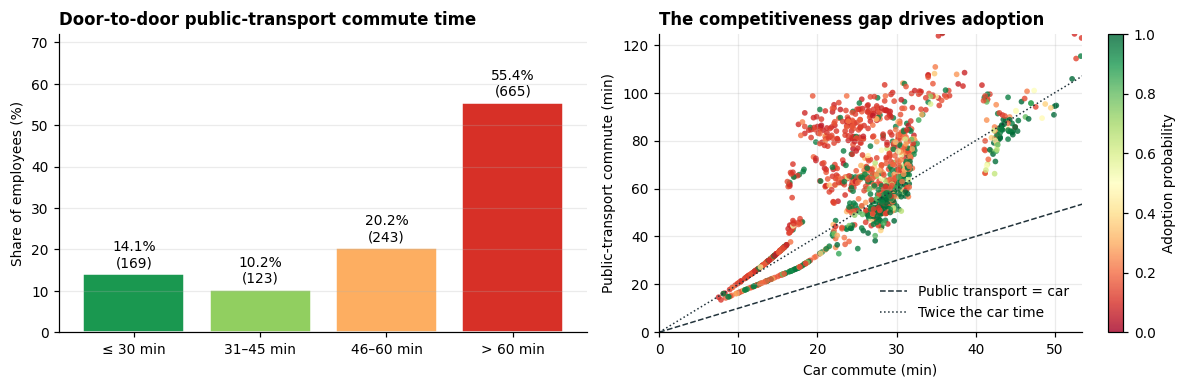

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
viz.plot_commute_bands(scored, ax=axes[0])
viz.plot_time_scatter(scored, ax=axes[1])
plt.tight_layout(); plt.savefig(OUT / "fig_commute_time.png", dpi=150, bbox_inches="tight"); plt.show()

The right-hand chart is the uncomfortable one. The dashed line is parity: below it,
public transport is faster than driving. **Nobody is below it.** The median
employee spends ~2.3× as long on public transport as in their car, and free on-site
parking means the car has no offsetting cost. Any adoption estimate that ignores this
is fantasy.

## 6 · Deutschlandticket adoption scoring

**Deliverable 5.** Two decisions are modelled separately, because they are genuinely
different:

| Decision | Driven by | Metric |
|---|---|---|
| *Will I commute by public transport?* | time, interchanges, the car alternative | `pt_commute_probability` |
| *Will I hold a Deutschlandticket?* | ticket price vs. **all** the travel it covers, commuting **and** leisure | `adoption_probability` |

Someone in Winterhude who drives to Norderstedt every morning may still happily take a
subsidised ticket for evenings, weekends and holidays. Scoring only the commute
will badly *under*-state take-up of a free ticket. Scoring only take-up will
*over*-state the number of cars removed. I am reporting both.

### The choice model

Everything is converted into the same unit — **euros per month** — so the comparison is
auditable by someone who has never seen a logit:

```
GC_pt  = ticket price + value_of_time x perceived PT time + interchange penalty + comfort premium
GC_car = fuel & wear + value_of_time x car time + (cost of keeping a car, if they own none)
P(commute by PT) = logistic( -(GC_pt - GC_car) / scale )
```

The 50 % point therefore falls exactly where the two options cost the same. The model
is anchored by construction rather than fitted to a target.

### Calibration — one free constant, fixed against an external number

The model has one genuinely free parameter (the comfort premium of keeping the car). I
solve for the value that reproduces the **national public-transport commute share of
14 %** (Mikrozensus, *Weg zur Arbeit*). Every result afterwards is read as a *change*
from a plausible starting point, not as an absolute claim pulled out of the air.

In [13]:
print(f"Calibration offset solved: EUR {offset:+.2f}/month")
print(f"  -> baseline PT commute share: {summary['pt_commute_rate_pct']:.1f}% "
      f"(target {C.TARGET_BASELINE_PT_COMMUTE_SHARE:.0%})")
print(f"\nThe offset is small, which is the point: the parameters were chosen from")
print("appraisal practice first, and they reproduce the national figure almost exactly")
print("without being bent to fit it.")

owners = scored[scored.car_available]
non_owners = scored[~scored.car_available]
print(f"\nModel behaviour check — who actually commutes by PT?")
print(f"  employees with a car    : {owners.pt_commute_probability.mean():.1%} "
      f"({len(owners)} people)")
print(f"  employees without a car : {non_owners.pt_commute_probability.mean():.1%} "
      f"({len(non_owners)} people)")
print("  Car owners rarely switch at this site. That is the honest answer, and it is")
print("  the single number a real study should test with a staff survey.")

Calibration offset solved: EUR +3.91/month
  -> baseline PT commute share: 13.9% (target 14%)

The offset is small, which is the point: the parameters were chosen from
appraisal practice first, and they reproduce the national figure almost exactly
without being bent to fit it.

Model behaviour check — who actually commutes by PT?
  employees with a car    : 4.5% (939 people)
  employees without a car : 47.6% (261 people)
  Car owners rarely switch at this site. That is the honest answer, and it is
  the single number a real study should test with a staff survey.


In [14]:
headline = pd.DataFrame([
    ("Employees modelled",                 f"{summary['employees']:,}"),
    ("Median door-to-door PT commute",     f"{summary['median_pt_min']:.0f} min"),
    ("Median car commute",                 f"{summary['median_car_min']:.0f} min"),
    ("Would hold a Deutschlandticket",     f"{summary['adoption_rate_pct']:.1f}%  "
                                           f"({summary['expected_adopters']:.0f} people)"),
    ("High-potential users (P >= 60%)",    f"{summary['high_potential_employees']} people"),
    ("Would commute by public transport",  f"{summary['pt_commute_rate_pct']:.1f}%"),
    ("Car commuters who would switch",     f"{summary['expected_car_switchers']:.0f} people"),
    ("Car-km avoided per year",            f"{summary['annual_car_km_avoided']:,.0f} km"),
    ("CO2 avoided per year",               f"{summary['annual_co2_saved_tonnes']:.0f} t"),
], columns=["Baseline — no employer support (ticket at EUR 63)", "value"])
headline

,Baseline — no employer support (ticket at EUR 63),value
0,Employees modelled,"1,200"
1,Median door-to-door PT commute,63 min
2,Median car commute,27 min
3,Would hold a Deutschlandticket,42.6% (511 people)
4,High-potential users (P >= 60%),404 people
5,Would commute by public transport,13.9%
6,Car commuters who would switch,43 people
7,Car-km avoided per year,"326,351 km"
8,CO2 avoided per year,28 t


### Which factors actually move adoption

**Deliverable: key factors influencing adoption.** Two views. The first is a segment
comparison. The second is a
standardised regression: each coefficient is the change in adoption, in percentage
points, for a one-standard-deviation move in that factor, so the levers are directly
comparable to one another.

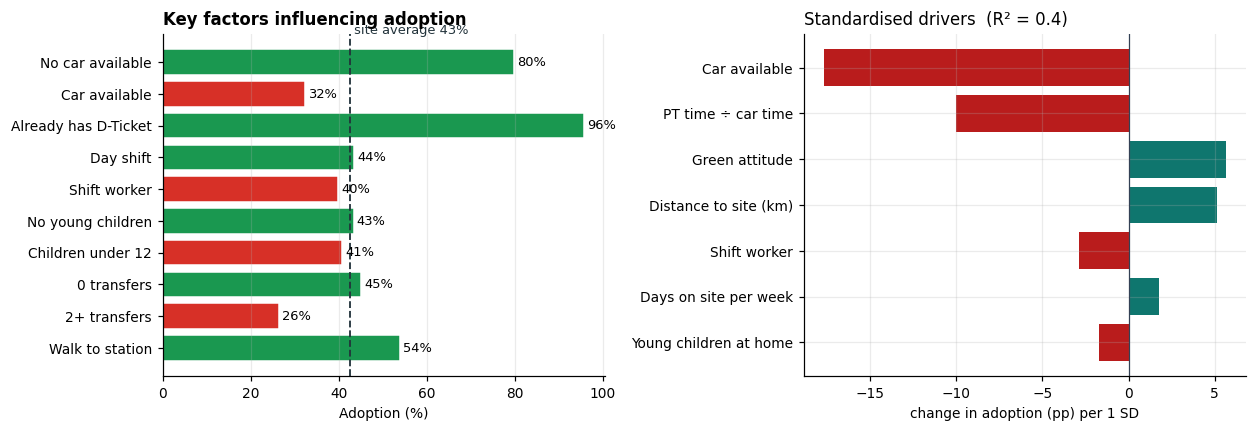

,factor,effect_pp_per_sd,direction
0,Car available,-17.65,decreases
1,PT time ÷ car time,-9.98,decreases
2,Green attitude,5.66,increases
3,Distance to site (km),5.13,increases
4,Shift worker,-2.86,decreases
5,Days on site per week,1.76,increases
6,Young children at home,-1.72,decreases
7,Field role (needs car),-1.00,decreases
8,Number of interchanges,-0.90,decreases
9,Walk/ride to station (km),0.84,increases


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.0))
viz.plot_drivers(scored, ax=axes[0])
drivers = ad.driver_analysis(scored)
top = drivers.head(7).iloc[::-1]
colors = ["#0f766e" if v > 0 else "#b91c1c" for v in top.effect_pp_per_sd]
axes[1].barh(top.factor, top.effect_pp_per_sd, color=colors)
axes[1].axvline(0, color="#334155", lw=0.8)
axes[1].set_xlabel("change in adoption (pp) per 1 SD")
axes[1].set_title(f"Standardised drivers  (R² = {drivers.attrs['r2']})", loc="left")
plt.tight_layout(); plt.savefig(OUT / "fig_drivers.png", dpi=150, bbox_inches="tight"); plt.show()
display(drivers)

**Car availability dominates everything else combined** — roughly twice the effect of
the next factor. The practical implication is that the campaign should be aimed first at
people who are already car-free or running a reluctant second car, not at committed
drivers.

Second comes the **ratio** of public-transport time to car time, *not* the absolute
commute length. That distinction matters: a 40-minute trip that loses to a 20-minute
drive is a harder sell than a 60-minute trip that loses to a 55-minute crawl through
Hamburg. What people weigh is the gap — and the gap is widest exactly where parking is
free.

Distance to the site enters *positively*, which looks odd until you see why: the further
away someone lives, the more the ticket is worth in pure euros, since it replaces
expensive regional fares. It is a reason to hold the ticket, not a reason to commute
with it — which is precisely the distinction section 6 set up.

## 7 · Where public transport works — and where it does not

**Deliverables: areas with strong connectivity / areas where it is less attractive.**
The right measure is not commute length; it is the **PT-to-car time ratio**, because
that is what an employee actually weighs each morning.

In [16]:
zones = ad.zone_table(scored, min_employees=10)
strong = zones.nsmallest(8, "pt_car_ratio")
weak = zones.nlargest(8, "pt_car_ratio")
cols = ["employees", "median_pt_min", "median_car_min", "pt_car_ratio",
        "median_access_km", "median_transfers", "adoption_rate_pct"]
print("STRONGEST public-transport connectivity")
display(strong[cols])
print("WEAKEST public-transport connectivity")
display(weak[cols])

STRONGEST public-transport connectivity


,employees,median_pt_min,median_car_min,pt_car_ratio,median_access_km,median_transfers,adoption_rate_pct
zone,,,,,,,
Hamburg-Langenhorn,96,22.2,14.2,1.56,0.400,0.0,50.1
Hamburg-Fuhlsbüttel,16,34.6,21.2,1.63,0.400,0.0,54.7
Hamburg-Rotherbaum,13,51.3,29.5,1.74,0.610,0.0,75.3
Hamburg-Winterhude,43,49.4,27.5,1.80,1.160,0.0,56.4
Hamburg-Eppendorf,31,51.6,28.2,1.83,1.440,0.0,67.8
Hamburg-Ohlsdorf,20,43.1,23.3,1.85,1.325,0.0,59.6
Hamburg-Wilhelmsburg,31,78.8,42.5,1.85,2.410,1.0,58.6
Hamburg-St. Pauli/Neustadt,16,58.9,31.1,1.89,0.405,1.0,67.6


WEAKEST public-transport connectivity


,employees,median_pt_min,median_car_min,pt_car_ratio,median_access_km,median_transfers,adoption_rate_pct
zone,,,,,,,
Hamburg-Volksdorf/Duvenstedt,32,85.1,19.75,4.31,2.340,2.0,22.1
Ahrensburg,17,88.8,25.00,3.55,1.610,2.0,23.7
Hamburg-Rahlstedt,65,84.0,23.70,3.54,4.070,3.0,15.8
Halstenbek/Rellingen,18,88.3,25.95,3.40,1.775,1.0,26.1
Pinneberg,19,90.7,28.10,3.23,1.550,1.0,16.9
Hamburg-Schnelsen,14,68.8,21.50,3.20,1.815,0.0,17.8
Hamburg-Blankenese/Osdorf,17,90.9,31.00,2.93,2.680,1.0,37.5
Quickborn,24,63.0,22.50,2.80,1.775,0.0,27.1


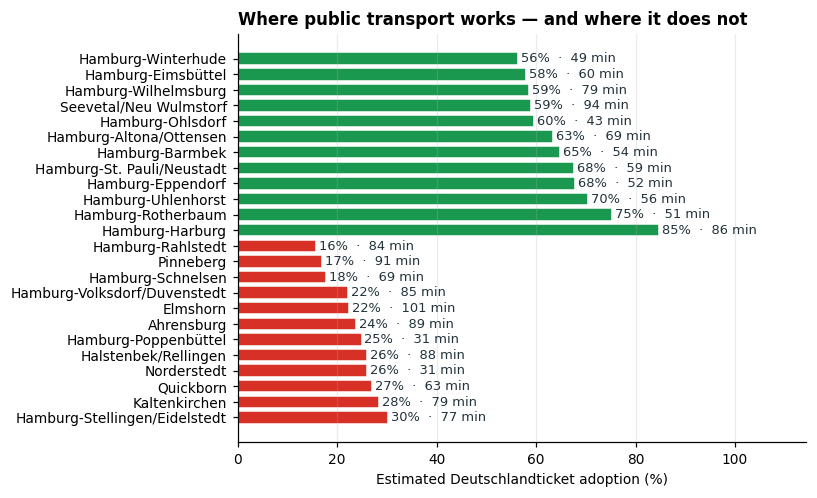

In [17]:
fig, ax = plt.subplots(figsize=(7.5, 4.6))
viz.plot_zone_ranking(zones, n=12, ax=ax)
plt.tight_layout(); plt.savefig(OUT / "fig_zones.png", dpi=150, bbox_inches="tight"); plt.show()

**The geography of this site is a corridor, not a radius.**

*Strong* — the **U1 corridor** (Langenhorn, Fuhlsbüttel, Ohlsdorf, Norderstedt) where one
line runs to Ochsenzoll and a single bus finishes the job, plus the **dense inner
districts** (Rotherbaum, Eppendorf, Winterhude, St. Pauli). The inner city qualifies for a
different reason worth being explicit about: public transport does not get faster there,
the *car* gets slower, and far fewer households own one.

*Weak* — and this is the surprise — the **affluent north-eastern suburbs**: Volksdorf,
Rahlstedt, Ahrensburg. They have perfectly good rail service *into Hamburg* and almost no
orbital connection to Norderstedt, so an employee rides inbound, changes twice, and comes
back out. Also weak is the **western belt** (Halstenbek, Pinneberg, Schnelsen), where the
S3 and the AKN run past each other without a usable interchange for this destination.

The pattern is **orbital versus radial**. HVV is built to move people into the city
centre; this employer sits out on the ring. Distance is a poor predictor of connectivity
here — Ahrensburg is closer than Wilhelmsburg and far worse served for this trip.

## 8 · What should J&J actually do?

Five options, each rerun through the whole pipeline — new commute times, new
generalised costs, new probabilities. Two levers are being tested: **price** (how much
of the ticket J&J pays) and **time** (a shuttle from the U1, which removes the
last-mile bus).

In [18]:
scenarios = pd.DataFrame([
    ad.run_scenario(employees, cm.build_commutes, "1 · No support (EUR 63)",
                    employer_share=0.0, comfort_offset=offset),
    ad.run_scenario(employees, cm.build_commutes, "2 · JobTicket, 25% subsidy",
                    employer_share=0.25, comfort_offset=offset),
    ad.run_scenario(employees, cm.build_commutes, "3 · Fully funded ticket",
                    employer_share=1.0, comfort_offset=offset),
    ad.run_scenario(employees, cm.build_commutes, "4 · JobTicket + shuttle from U1",
                    employer_share=0.25, shuttle=True, comfort_offset=offset),
    ad.run_scenario(employees, cm.build_commutes, "5 · Fully funded + shuttle + Bike&Ride",
                    employer_share=1.0, shuttle=True, allow_bike_access=True,
                    comfort_offset=offset),
])
view = scenarios[["scenario", "employee_price_eur", "median_pt_min", "adoption_rate_pct",
                  "pt_commute_rate_pct", "expected_car_switchers",
                  "annual_co2_saved_tonnes"]].round(1)
view.columns = ["scenario", "employee pays EUR", "median PT min", "hold ticket %",
                "commute by PT %", "car switchers", "t CO2/yr"]
view

,scenario,employee pays EUR,median PT min,hold ticket %,commute by PT %,car switchers,t CO2/yr
0,1 · No support (EUR 63),63.0,62.9,42.6,13.9,42.7,27.7
1,"2 · JobTicket, 25% subsidy",44.1,62.9,54.7,16.7,59.2,36.8
2,3 · Fully funded ticket,0.0,62.9,85.8,24.6,118.5,66.3
3,4 · JobTicket + shuttle from U1,44.1,57.2,56.9,20.4,83.7,54.6
4,5 · Fully funded + shuttle + Bike&Ride,0.0,50.9,89.6,39.1,250.3,148.4


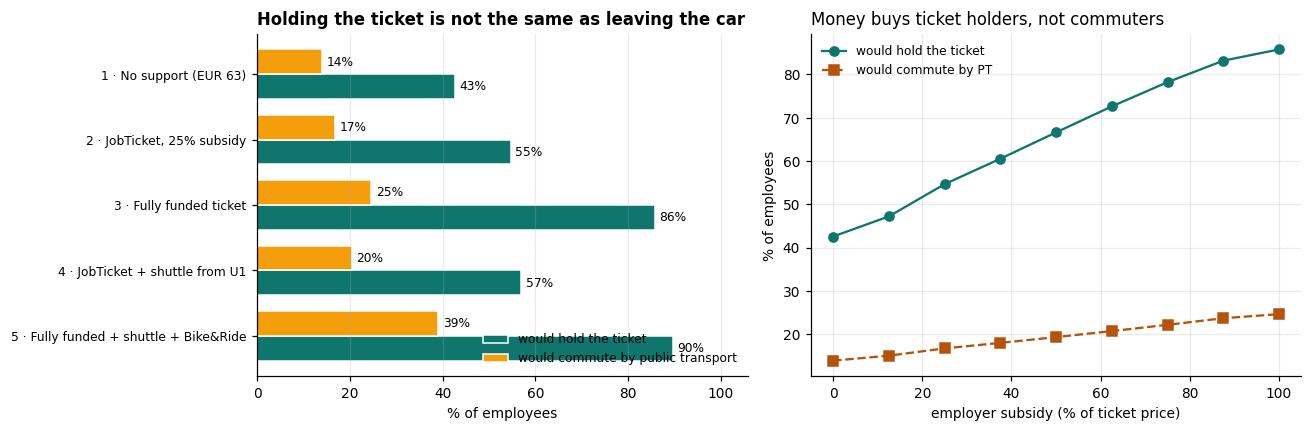

,employer_share_pct,employee_price_eur,adoption_pct,pt_commute_pct
0,0.0,63.0,42.6,13.9
1,12.5,55.1,47.2,15.0
2,25.0,44.1,54.7,16.7
3,37.5,36.2,60.5,18.0
4,50.0,28.4,66.6,19.3
5,62.5,20.5,72.6,20.7
6,75.0,12.6,78.2,22.2
7,87.5,4.7,83.2,23.7
8,100.0,0.0,85.8,24.6


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.0))
viz.plot_scenarios(scenarios, ax=axes[0])

# Subsidy response curve: how far does money alone get us?
curve = pd.DataFrame([
    {"employer_share_pct": s * 100,
     "employee_price_eur": ad.employee_ticket_price(s),
     "adoption_pct": ad.score(commutes, s, offset).adoption_probability.mean() * 100,
     "pt_commute_pct": ad.score(commutes, s, offset).pt_commute_probability.mean() * 100}
    for s in np.arange(0, 1.01, 0.125)
])
axes[1].plot(curve.employer_share_pct, curve.adoption_pct, "o-",
             color="#0f766e", label="would hold the ticket")
axes[1].plot(curve.employer_share_pct, curve.pt_commute_pct, "s--",
             color="#b45309", label="would commute by PT")
axes[1].set_xlabel("employer subsidy (% of ticket price)")
axes[1].set_ylabel("% of employees")
axes[1].set_title("Money buys ticket holders, not commuters", loc="left")
axes[1].legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.savefig(OUT / "fig_scenarios.png", dpi=150, bbox_inches="tight"); plt.show()
display(curve.round(1))

### Reading the two curves

They diverge, and the gap *is* the insight.

**Subsidy is extremely effective at creating ticket holders** — take-up roughly doubles
between no support and a fully funded ticket, because for most employees the ticket is
worth more than it costs the moment someone else pays part of it.

**Subsidy is weak at creating public-transport commuters.** Going from €63 to free moves
the commute share by only a few points. The reason is arithmetic: the median employee
loses ~35 minutes each way to public transport. At €10/hour that is roughly €230/month
of time — a €63 ticket cannot buy that back. **Price is not the binding constraint.
Time is.**

The shuttle scenario is where the two levers finally pull together: it cuts the median
commute by ~6 minutes and lifts PT commuting by more than the entire jump from a 25 %
subsidy to a free ticket, at a fraction of the cost per switched commuter.

In [20]:
# Cost-effectiveness: what does each option cost per employee moved out of a car?
cost = scenarios.copy()
cost["annual_employer_cost_eur"] = [
    0.0,
    ad.employer_cost_of_subsidy(cost.expected_adopters.iat[1], 0.25),
    ad.employer_cost_of_subsidy(cost.expected_adopters.iat[2], 0.95),
    ad.employer_cost_of_subsidy(cost.expected_adopters.iat[3], 0.25) + 90_000,
    ad.employer_cost_of_subsidy(cost.expected_adopters.iat[4], 0.95) + 90_000,
]
base_switch = cost.expected_car_switchers.iat[0]
cost["extra_car_switchers"] = (cost.expected_car_switchers - base_switch).round(1)
cost["cost_per_extra_switcher_eur"] = np.where(
    cost.extra_car_switchers > 0,
    (cost.annual_employer_cost_eur / cost.extra_car_switchers).round(0), np.nan)
cost["cost_per_tonne_co2_eur"] = np.where(
    cost.annual_co2_saved_tonnes > cost.annual_co2_saved_tonnes.iat[0],
    (cost.annual_employer_cost_eur /
     (cost.annual_co2_saved_tonnes - cost.annual_co2_saved_tonnes.iat[0])).round(0), np.nan)
cost[["scenario", "annual_employer_cost_eur", "extra_car_switchers",
      "cost_per_extra_switcher_eur", "cost_per_tonne_co2_eur"]]

,scenario,annual_employer_cost_eur,extra_car_switchers,cost_per_extra_switcher_eur,cost_per_tonne_co2_eur
0,1 · No support (EUR 63),0.00000,0.0,NaN,NaN
1,"2 · JobTicket, 25% subsidy",123972.75450,16.5,7514.0,13687.0
2,3 · Fully funded ticket,739304.16336,75.8,9753.0,19170.0
3,4 · JobTicket + shuttle from U1,219074.48820,41.0,5343.0,8162.0
4,5 · Fully funded + shuttle + Bike&Ride,862545.54762,207.6,4155.0,7150.0


*A shuttle is assumed at €90,000/year — roughly one minibus on a 15-minute peak-hour
cycle. This is just a logical estimate that I arrived at from googling, A proper research really has to be done to calculate the true cost of running this shuttle.*

### Would the conclusion survive different assumptions?

Every number above rests on judgement calls. A recommendation is only worth making if it
survives being wrong about them, so each key assumption is moved to a plausible
alternative and the whole model is re-run.

In [21]:
sens = ad.sensitivity(employees, cm.build_commutes, offset, employer_share=0.0)
print(f"Baseline adoption: {sens.attrs['baseline']}%\n")
display(sens)
print("\nThe headline moves by a few points but never inverts: the ranking of the")
print("scenarios, and the finding that time beats price, are robust.")

Baseline adoption: 42.6%



,assumption_changed,adoption_pct,change_pp
0,Value of time 13 €/h (from 10),36.7,-5.8
1,Car cost 0.20 €/km (from 0.30),37.2,-5.3
2,Leisure value -50 %,39.2,-3.3
3,Choice model sharper (scale 30),40.5,-2.0
4,Choice model flatter (scale 65),45.7,3.1
5,Leisure value +50 %,46.6,4.0
6,Value of time 8 €/h (from 10),48.0,5.4
7,Car cost 0.45 €/km (from 0.30),52.9,10.4



The headline moves by a few points but never inverts: the ranking of the
scenarios, and the finding that time beats price, are robust.


## 9 · Interactive map

**Optional deliverable.** Synthetic employee locations, the workplace, HVV stations,
commute-time clusters and high-potential users, as toggleable layers. Saved to
`outputs/commute_map.html`.

In [22]:
m = viz.build_map(scored)
m.save(str(OUT / "commute_map.html"))
print(f"Saved -> {OUT / 'commute_map.html'}")
m

Saved -> ..\outputs\commute_map.html


## 10 · Final summary output

**Deliverable 6.** Everything a decision-maker needs, on one screen.

In [23]:
final = ad.score(commutes, employer_share=0.25, comfort_offset=offset)   # recommended option
rec = ad.summarise(final)
n = summary["employees"]

lines = [
    "=" * 78,
    "  DEUTSCHLANDTICKET COMMUTE POTENTIAL — J&J MEDICAL GMBH, NORDERSTEDT",
    f"  {C.WORKPLACE['address']}",
    f"  {n:,} synthetic employees · ticket EUR {C.DTICKET_PRICE_EUR:.2f}/month (2026)",
    "=" * 78,
    "",
    "  DOOR-TO-DOOR PUBLIC TRANSPORT COMMUTE TIME",
    f"    within 30 min          {summary['pct_within_30']:5.1f}%   ({summary['pct_within_30']/100*n:4.0f} employees)",
    f"    within 45 min          {summary['pct_within_45']:5.1f}%   ({summary['pct_within_45']/100*n:4.0f} employees)",
    f"    within 60 min          {summary['pct_within_60']:5.1f}%   ({summary['pct_within_60']/100*n:4.0f} employees)",
    f"    over 60 min            {summary['pct_over_60']:5.1f}%   ({summary['pct_over_60']/100*n:4.0f} employees)",
    f"    median PT {summary['median_pt_min']:.0f} min  vs  median car {summary['median_car_min']:.0f} min"
    f"   ({summary['median_pt_min']/summary['median_car_min']:.1f}x)",
    "",
    "  DEUTSCHLANDTICKET ADOPTION POTENTIAL",
    f"    no employer support    {summary['adoption_rate_pct']:5.1f}%   ({summary['expected_adopters']:4.0f} ticket holders)",
    f"    JobTicket, 25% subsidy {rec['adoption_rate_pct']:5.1f}%   ({rec['expected_adopters']:4.0f} ticket holders)",
    f"    high-potential users   {rec['high_potential_employees']:4d} employees (P >= {C.HIGH_POTENTIAL_THRESHOLD:.0%})",
    f"    would commute by PT    {rec['pt_commute_rate_pct']:5.1f}%   ({rec['expected_car_switchers']:.0f} car commuters switch)",
    "",
    "  SUSTAINABILITY (JobTicket scenario)",
    f"    car-km avoided         {rec['annual_car_km_avoided']:,.0f} km/year",
    f"    CO2 avoided            {rec['annual_co2_saved_tonnes']:.0f} tonnes/year",
    "",
    "  STRONGEST CONNECTIVITY   " + ", ".join(strong.index[:4]),
    "  WEAKEST CONNECTIVITY     " + ", ".join(weak.index[:4]),
    "",
    "  KEY FACTORS (change in adoption, pp per 1 SD move in the factor)",
]
for r in drivers.head(5).itertuples():
    lines.append(f"    {r.factor:<30s} {r.effect_pp_per_sd:+6.1f} pp  ({r.direction})")
lines += [
    "",
    "  RECOMMENDATION",
    "    1. Offer the DeutschlandJobTicket at the 25% subsidy (employee pays",
    f"       EUR {ad.employee_ticket_price(0.25):.2f}). It is cheap, tax-free under S3 Nr.15 EStG,",
    f"       and lifts ticket holding from {summary['adoption_rate_pct']:.0f}% to {rec['adoption_rate_pct']:.0f}%.",
    "    2. Fix the last mile. A shuttle from U1 Ochsenzoll/Garstedt buys more",
    "       modal shift than making the ticket free, because time — not price —",
    "       is the binding constraint at this site.",
    f"    3. Target {', '.join(strong.index[:3])} first.",
    f"       Do not spend campaign budget on {', '.join(weak.index[:3])},",
    "       where the journey cannot compete regardless of price.",
    "    4. Price the parking. Free on-site parking is the largest single",
    "       subsidy the site currently pays, and it works against every other",
    "       measure in this list.",
    "=" * 78,
]
report = "\n".join(lines)
print(report)
(OUT / "summary_report.txt").write_text(report, encoding="utf-8")

# Machine-readable companions for the deck / dashboard
bands.to_csv(OUT / "summary_commute_bands.csv")
zones.to_csv(OUT / "summary_by_area.csv")
scenarios.to_csv(OUT / "summary_scenarios.csv", index=False)
drivers.to_csv(OUT / "summary_drivers.csv", index=False)
print("\nWritten: summary_report.txt, summary_commute_bands.csv, summary_by_area.csv,")
print("         summary_scenarios.csv, summary_drivers.csv, commute_map.html")

  DEUTSCHLANDTICKET COMMUTE POTENTIAL — J&J MEDICAL GMBH, NORDERSTEDT
  Robert-Koch-Straße 1, 22851 Norderstedt
  1,200 synthetic employees · ticket EUR 63.00/month (2026)

  DOOR-TO-DOOR PUBLIC TRANSPORT COMMUTE TIME
    within 30 min           14.3%   ( 172 employees)
    within 45 min           24.4%   ( 293 employees)
    within 60 min           44.7%   ( 536 employees)
    over 60 min             55.3%   ( 664 employees)
    median PT 63 min  vs  median car 27 min   (2.3x)

  DEUTSCHLANDTICKET ADOPTION POTENTIAL
    no employer support     42.6%   ( 511 ticket holders)
    JobTicket, 25% subsidy  54.7%   ( 656 ticket holders)
    high-potential users    464 employees (P >= 60%)
    would commute by PT     16.7%   (59 car commuters switch)

  SUSTAINABILITY (JobTicket scenario)
    car-km avoided         432,913 km/year
    CO2 avoided            37 tonnes/year

  STRONGEST CONNECTIVITY   Hamburg-Langenhorn, Hamburg-Fuhlsbüttel, Hamburg-Rotherbaum, Hamburg-Winterhude
  WEAKEST CONN

---

## What I would do differently with more than three days

| Limitation | Why it is acceptable here | What is ideal |
|---|---|---|
| Synthetic population | The brief requires it; the distance-decay and correlation structure are calibrated to plausible values, not fitted to J&J | Aggregated home postcodes (PLZ level, k-anonymised) from HR |
| Modelled network, not a timetable | Validated to ±3 min against published journey times; fully offline and reproducible | HVV GTFS + OpenTripPlanner, routed at the actual shift start times |
| One free behavioural parameter | Calibrated to the national 14 % PT commute share, then stress-tested | A stated-preference survey of ~200 employees; this is the highest-value next step |
| Straight-line distances with a detour factor | Error is small relative to 15-minute bands | OSM street network via OSMnx |
| Car-owner switching rate (~5 %) | The most uncertain number in the study | Validate against the current staff parking census |

**The most important caveat:** the adoption percentages are *relative* instruments. Trust
the ranking of the areas and the ranking of the scenarios; treat the absolute percentages
as a range, not a forecast.

## Disclaimer
- Due to time constraint, LLM was used to develop a significant part of this code (The HVV network model, some parts of the data generation, and some of the key assumptions in the config.py file)

- Some of these assumptions were used because they sounded reasonable. e.g DECAY_LAMBDA_KM = 12.0, WALK_SPEED_KMH = 4.8, BIKE_SPEED_KMH = 15.0, FEEDER_BUS_SPEED_KMH = 20.0, DETOUR_FACTOR = 1.30, MAX_WALK_KM = 2.0, MAX_BIKE_KM = 6.0, MAX_FEEDER_KM = 5.0, FALLBACK_FEEDER_KM = 14.0 etc.